In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [236]:
df = pd.read_csv("garments_worker_productivity.csv")

In [237]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [238]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [239]:
missing_count = df.isnull().sum()

print("Missing Values:")
print(missing_count)

# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

Missing Values:
date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

Missing Value Percentage:
date                      0.000000
quarter                   0.000000
department                0.000000
day                       0.000000
team                      0.000000
targeted_productivity     0.000000
smv                       0.000000
wip                      42.272348
over_time                 0.000000
incentive                 0.000000
idle_time                 0.000000
idle_men                  0.000000
no_of_style_change        0.000000
no_of_workers             0.000000
actual_productivity

In [240]:
df["wip"] = df["wip"].fillna(0)
print("Missing WIP values:", df["wip"].isna().sum())

Missing WIP values: 0


In [241]:
missing_count = df.isnull().sum()

print("Missing Values:")
print(missing_count)

# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

Missing Values:
date                     0
quarter                  0
department               0
day                      0
team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
actual_productivity      0
dtype: int64

Missing Value Percentage:
date                     0.0
quarter                  0.0
department               0.0
day                      0.0
team                     0.0
targeted_productivity    0.0
smv                      0.0
wip                      0.0
over_time                0.0
incentive                0.0
idle_time                0.0
idle_men                 0.0
no_of_style_change       0.0
no_of_workers            0.0
actual_productivity      0.0
dtype: float64


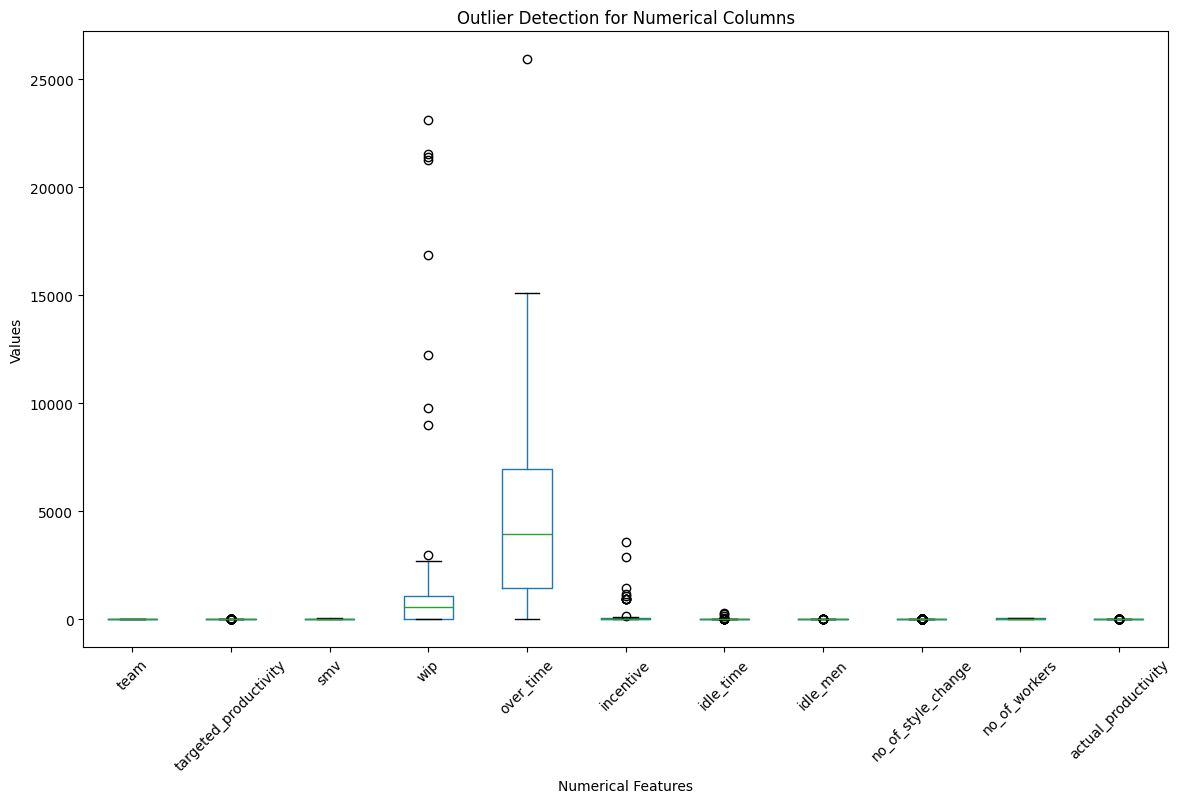

In [242]:
# Select numerical columns
numeric_cols = df.select_dtypes(include="number").columns

# Create boxplots
plt.figure(figsize=(14, 8))

df[numeric_cols].boxplot()

plt.title("Outlier Detection for Numerical Columns")
plt.xlabel("Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(False)

plt.show()

In [243]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

team: 0 outliers
targeted_productivity: 79 outliers
smv: 0 outliers
wip: 9 outliers
over_time: 1 outliers
incentive: 11 outliers
idle_time: 18 outliers
idle_men: 18 outliers
no_of_style_change: 147 outliers
no_of_workers: 0 outliers
actual_productivity: 54 outliers


In [244]:
for col in numeric_cols:

    # Calculate Q1, Q3 and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # IQR boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove missing values
    values = df[col].dropna()

    # Normal values
    normal_lower = values[values >= lower_bound]
    normal_upper = values[values <= upper_bound]

    # Outliers
    lower_outliers = values[values < lower_bound]
    upper_outliers = values[values > upper_bound]

    print("\n" + "=" * 60)
    print("Column:", col)
    print("Median:", df[col].median())

    print("\nLower boundary:", lower_bound)
    print("Upper boundary:", upper_bound)

    if len(normal_lower) > 0:
        print("First normal value after lower boundary:",
              normal_lower.min())

    if len(normal_upper) > 0:
        print("Last normal value before upper outliers:",
              normal_upper.max())

    print("\nLower outliers:")
    print(sorted(lower_outliers.unique()))

    print("\nUpper outliers:")
    print(sorted(upper_outliers.unique()))


Column: team
Median: 6.0

Lower boundary: -6.0
Upper boundary: 18.0
First normal value after lower boundary: 1
Last normal value before upper outliers: 12

Lower outliers:
[]

Upper outliers:
[]

Column: targeted_productivity
Median: 0.75

Lower boundary: 0.5499999999999998
Upper boundary: 0.9500000000000002
First normal value after lower boundary: 0.6
Last normal value before upper outliers: 0.8

Lower outliers:
[np.float64(0.07), np.float64(0.35), np.float64(0.4), np.float64(0.5)]

Upper outliers:
[]

Column: smv
Median: 15.26

Lower boundary: -26.54
Upper boundary: 54.74
First normal value after lower boundary: 2.9
Last normal value before upper outliers: 54.56

Lower outliers:
[]

Upper outliers:
[]

Column: wip
Median: 586.0

Lower boundary: -1624.5
Upper boundary: 2707.5
First normal value after lower boundary: 0.0
Last normal value before upper outliers: 2698.0

Lower outliers:
[]

Upper outliers:
[np.float64(2984.0), np.float64(8992.0), np.float64(9792.0), np.float64(12261.0),

In [245]:
day_mapping = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["day"] = df["day"].map(day_mapping)

In [246]:
print(df["day"].head())

0    4
1    4
2    4
3    4
4    4
Name: day, dtype: int64


In [247]:
df = df.drop(columns=["date"])

In [248]:
print(df.columns)

Index(['quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv',
       'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')


In [249]:
print(df["department"].unique())

['sweing' 'finishing ' 'finishing']


In [250]:
df["department"] = df["department"].str.strip()

In [251]:
print(df["department"].unique())

['sweing' 'finishing']


In [252]:
department_mapping = {
    "sweing": 0,
    "finishing": 1
}

df["department"] = df["department"].map(department_mapping)

In [253]:
df.head()['department']
# 0 = sewing, 1 = finishing

0    0
1    1
2    0
3    0
4    0
Name: department, dtype: int64

In [254]:
quarter_mapping = {
    "Quarter1": 1,
    "Quarter2": 2,
    "Quarter3": 3,
    "Quarter4": 4,
    "Quarter5": 5
}

df["quarter"] = df["quarter"].map(quarter_mapping)

In [255]:
print(df["quarter"].unique())

[1 2 3 4 5]


In [256]:
X = df.drop(columns=["actual_productivity"])
y = df["actual_productivity"].values

In [257]:
np.random.seed(42)

indices = np.arange(len(df))
np.random.shuffle(indices)

split = int(0.8 * len(df))

train_indices = indices[:split]
test_indices = indices[split:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 957
Testing samples: 240


In [258]:
print(X_train.dtypes)

quarter                    int64
department                 int64
day                        int64
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
dtype: object


In [259]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1197, 13)
y shape: (1197,)


In [260]:
X = df.drop(columns=["actual_productivity"]).values
y = df["actual_productivity"].values
np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.8 * len(X))

train_indices = indices[:split]
test_indices = indices[split:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (957, 13)
X_test: (240, 13)
y_train: (957,)
y_test: (240,)


In [261]:
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

print("X_train_bias:", X_train_bias.shape)
print("X_test_bias:", X_test_bias.shape)

X_train_bias: (957, 14)
X_test_bias: (240, 14)


In [262]:
import time

start_time = time.time()
beta = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train
manual_lr_train_time = time.time() - start_time

print("Coefficients:")
print(beta)
print(f"Manual Linear Regression training time: {manual_lr_train_time:.6f} s")

Coefficients:
[ 2.02330801e-01  5.96391932e-03  6.03165089e-02  2.55285590e-04
 -7.57641763e-03  6.85970560e-01 -7.06220583e-03  6.00297326e-06
 -3.73171797e-06  3.28537288e-05  3.88128951e-04 -8.26029102e-03
 -5.20523825e-02  4.93630379e-03]
Manual Linear Regression training time: 0.001003 s


In [263]:
start_time = time.time()
y_pred = X_test_bias @ beta
manual_lr_pred_time = time.time() - start_time

print("First 10 actual values:")
print(y_test[:10])
print(f"Manual Linear Regression prediction time: {manual_lr_pred_time:.6f} s")

First 10 actual values:
[0.61625    0.9520202  0.96178451 0.90666667 0.94998161 0.79997586
 0.47110849 0.35553448 0.80012872 0.75922839]
Manual Linear Regression prediction time: 0.000000 s


In [264]:
mae = np.mean(np.abs(y_test - y_pred))

print("MAE:", mae)

MAE: 0.10521704132678958


In [265]:
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("RMSE:", rmse)

RMSE: 0.14416580502675339


In [266]:
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("R² Score:", r2)

R² Score: 0.3255939750035799


In [267]:
print("Linear Regression from Scratch")
print("-------------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression from Scratch
-------------------------------
MAE : 0.10521704132678958
RMSE: 0.14416580502675339
R²  : 0.3255939750035799


In [268]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

In [269]:
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

In [270]:
X_train_scaled_bias = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_scaled_bias = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]

In [271]:
print("X_train_scaled_bias:", X_train_scaled_bias.shape)
print("X_test_scaled_bias:", X_test_scaled_bias.shape)

X_train_scaled_bias: (957, 14)
X_test_scaled_bias: (240, 14)


In [272]:
beta_scaled = np.linalg.inv(
    X_train_scaled_bias.T @ X_train_scaled_bias
) @ X_train_scaled_bias.T @ y_train

In [273]:
y_pred_scaled = X_test_scaled_bias @ beta_scaled

In [274]:
mae_scaled = np.mean(np.abs(y_test - y_pred_scaled))

rmse_scaled = np.sqrt(
    np.mean((y_test - y_pred_scaled) ** 2)
)

ss_res = np.sum((y_test - y_pred_scaled) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2_scaled = 1 - (ss_res / ss_tot)

print("Linear Regression with Scaling")
print("--------------------------------")
print("MAE :", mae_scaled)
print("RMSE:", rmse_scaled)
print("R²  :", r2_scaled)

Linear Regression with Scaling
--------------------------------
MAE : 0.1052170413267873
RMSE: 0.14416580502675053
R²  : 0.32559397500360654


In [275]:
# Training-only feature selection

# Create training dataframe using the same train indices
train_df = df.iloc[train_indices].copy()

# Calculate correlations using only training data
correlations = train_df.corr(numeric_only=True)["actual_productivity"].drop(
    "actual_productivity"
)

# Sort by absolute correlation
correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

print("Training-only correlations:")
print(correlations)

Training-only correlations:
targeted_productivity    0.407530
no_of_style_change      -0.202064
idle_men                -0.184281
team                    -0.141531
smv                     -0.107649
idle_time               -0.090478
department               0.073244
incentive                0.065435
no_of_workers           -0.037862
wip                      0.036623
quarter                 -0.034781
over_time               -0.018867
day                      0.012161
Name: actual_productivity, dtype: float64


In [276]:
selected_features = [
    "targeted_productivity",
    "department",
    "incentive",
    "wip",
    "smv",
    "team",
    "idle_men",
    "no_of_style_change",
    "no_of_workers",
    "over_time"
]

X_reduced = df[selected_features].values
y = df["actual_productivity"].values

print("Original number of features:", X.shape[1])
print("Reduced number of features:", X_reduced.shape[1])

Original number of features: 13
Reduced number of features: 10


In [277]:
X_train_reduced = X_reduced[train_indices]
X_test_reduced = X_reduced[test_indices]

y_train_reduced = y[train_indices]
y_test_reduced = y[test_indices]

print("X_train_reduced:", X_train_reduced.shape)
print("X_test_reduced:", X_test_reduced.shape)

X_train_reduced: (957, 10)
X_test_reduced: (240, 10)


In [278]:
X_train_reduced_bias = np.c_[
    np.ones(X_train_reduced.shape[0]),
    X_train_reduced
]

X_test_reduced_bias = np.c_[
    np.ones(X_test_reduced.shape[0]),
    X_test_reduced
]

print(X_train_reduced_bias.shape)
print(X_test_reduced_bias.shape)

(957, 11)
(240, 11)


In [279]:
beta_reduced = np.linalg.inv(
    X_train_reduced_bias.T @ X_train_reduced_bias
) @ X_train_reduced_bias.T @ y_train_reduced

print("Coefficients:")
print(beta_reduced)

Coefficients:
[ 2.23409964e-01  6.77555951e-01  6.04547936e-02  3.22057613e-05
  5.74790511e-06 -7.02602204e-03 -7.53614139e-03 -7.31943454e-03
 -4.99733439e-02  4.87867413e-03 -3.42591572e-06]


In [280]:
y_pred_reduced = X_test_reduced_bias @ beta_reduced

print("First 10 predictions:")
print(y_pred_reduced[:10])

First 10 predictions:
[0.78687714 0.78281937 0.78009885 0.74701773 0.86284169 0.74607657
 0.67038397 0.73446426 0.77926884 0.72812616]


In [281]:
mae_reduced = np.mean(
    np.abs(y_test_reduced - y_pred_reduced)
)

rmse_reduced = np.sqrt(
    np.mean((y_test_reduced - y_pred_reduced) ** 2)
)

ss_res = np.sum(
    (y_test_reduced - y_pred_reduced) ** 2
)

ss_tot = np.sum(
    (y_test_reduced - np.mean(y_test_reduced)) ** 2
)

r2_reduced = 1 - (ss_res / ss_tot)

print("Linear Regression with Feature Selection")
print("-----------------------------------------")
print("MAE :", mae_reduced)
print("RMSE:", rmse_reduced)
print("R²  :", r2_reduced)

Linear Regression with Feature Selection
-----------------------------------------
MAE : 0.10532950315166945
RMSE: 0.14380340363627972
R²  : 0.32898033267513827


In [282]:
lambda_value = 0.1

I = np.eye(X_train_reduced_bias.shape[1])

# Do not regularize the intercept
I[0, 0] = 0

beta_ridge = np.linalg.inv(
    X_train_reduced_bias.T @ X_train_reduced_bias
    + lambda_value * I
) @ X_train_reduced_bias.T @ y_train_reduced

print("Ridge coefficients:")
print(beta_ridge)

Ridge coefficients:
[ 2.29449194e-01  6.69808266e-01  6.01598226e-02  3.24465665e-05
  5.75537691e-06 -7.02455908e-03 -7.53201452e-03 -7.33241612e-03
 -5.03378579e-02  4.87407265e-03 -3.44808574e-06]


In [283]:
y_pred_ridge = X_test_reduced_bias @ beta_ridge

print("First 10 Ridge predictions:")
print(y_pred_ridge[:10])

First 10 Ridge predictions:
[0.78638764 0.78267256 0.77997316 0.74655398 0.86233771 0.74634911
 0.67033648 0.73472441 0.77871126 0.72831547]


In [284]:
mae_ridge = np.mean(
    np.abs(y_test_reduced - y_pred_ridge)
)

rmse_ridge = np.sqrt(
    np.mean((y_test_reduced - y_pred_ridge) ** 2)
)

ss_res = np.sum(
    (y_test_reduced - y_pred_ridge) ** 2
)

ss_tot = np.sum(
    (y_test_reduced - np.mean(y_test_reduced)) ** 2
)

r2_ridge = 1 - (ss_res / ss_tot)

print("Ridge Regression")
print("----------------")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

Ridge Regression
----------------
MAE : 0.1054613503062199
RMSE: 0.14386542182404258
R²  : 0.32840142568929953


In [285]:
lambda_values = [0.001, 0.01, 0.1, 1, 10, 100]

for lam in lambda_values:
    I = np.eye(X_train_reduced_bias.shape[1])
    I[0, 0] = 0

    beta_ridge_lam = np.linalg.inv(
        X_train_reduced_bias.T @ X_train_reduced_bias + lam * I
    ) @ X_train_reduced_bias.T @ y_train_reduced

    y_pred_ridge_lam = X_test_reduced_bias @ beta_ridge_lam

    mae_lam = np.mean(np.abs(y_test_reduced - y_pred_ridge_lam))
    rmse_lam = np.sqrt(np.mean((y_test_reduced - y_pred_ridge_lam) ** 2))
    ss_res = np.sum((y_test_reduced - y_pred_ridge_lam) ** 2)
    ss_tot = np.sum((y_test_reduced - np.mean(y_test_reduced)) ** 2)
    r2_lam = 1 - (ss_res / ss_tot)

    print("Lambda:", lam, "| MAE:", mae_lam, "| RMSE:", rmse_lam, "| R2:", r2_lam)

Lambda: 0.001 | MAE: 0.10533083737277796 | RMSE: 0.1438040119121796 | R2: 0.32897465595337894
Lambda: 0.01 | MAE: 0.10534283089363636 | RMSE: 0.1438094975195704 | R2: 0.3289234605556166
Lambda: 0.1 | MAE: 0.1054613503062199 | RMSE: 0.14386542182404258 | R2: 0.32840142568929953
Lambda: 1 | MAE: 0.10669525589630482 | RMSE: 0.1445038131238295 | R2: 0.3224278715575648
Lambda: 10 | MAE: 0.11450514261805049 | RMSE: 0.15065568356657813 | R2: 0.26350812629650955
Lambda: 100 | MAE: 0.12298204896940132 | RMSE: 0.16080774888193036 | R2: 0.1609055213070253


In [286]:
X = df.drop(columns=["actual_productivity"])
y = df["actual_productivity"]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (957, 13)
X_test: (240, 13)
y_train: (957,)
y_test: (240,)


In [287]:
from sklearn.linear_model import LinearRegression
import time

lr_model = LinearRegression()

start_time = time.time()
lr_model.fit(X_train, y_train)
sklearn_lr_train_time = time.time() - start_time

start_time = time.time()
y_pred_lr = lr_model.predict(X_test)
sklearn_lr_pred_time = time.time() - start_time

print(f"Scikit-learn LR training time: {sklearn_lr_train_time:.6f} s")
print(f"Scikit-learn LR prediction time: {sklearn_lr_pred_time:.6f} s")

Scikit-learn LR training time: 0.038586 s
Scikit-learn LR prediction time: 0.005132 s


In [288]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
    

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-----------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
-----------------
MAE : 0.10521704132678741
RMSE: 0.14416580502675067
R²  : 0.3255939750036053


In [289]:

from sklearn.linear_model import Ridge
import time

# Same target split as the manual reduced/ridge section (Cells 41-50)
y_train_reduced = y.iloc[train_indices] if hasattr(y, "iloc") else y[train_indices]
y_test_reduced = y.iloc[test_indices] if hasattr(y, "iloc") else y[test_indices]

# --- Scikit-learn Linear Regression, SAME reduced feature set as manual ---
lr_model_reduced = LinearRegression()

start_time = time.time()
lr_model_reduced.fit(X_train_reduced, y_train_reduced)
sklearn_lr_reduced_train_time = time.time() - start_time

start_time = time.time()
y_pred_lr_reduced = lr_model_reduced.predict(X_test_reduced)
sklearn_lr_reduced_pred_time = time.time() - start_time

mae_lr_reduced = np.mean(np.abs(y_test_reduced - y_pred_lr_reduced))
rmse_lr_reduced = np.sqrt(np.mean((y_test_reduced - y_pred_lr_reduced) ** 2))
ss_res = np.sum((y_test_reduced - y_pred_lr_reduced) ** 2)
ss_tot = np.sum((y_test_reduced - np.mean(y_test_reduced)) ** 2)
r2_lr_reduced = 1 - (ss_res / ss_tot)

# --- Scikit-learn Ridge, SAME lambda as your manual ridge cell (Cell 47 used 0.1) ---
ridge_model = Ridge(alpha=0.1)  # match whichever lambda you finalize from Cell 50's tuning

start_time = time.time()
ridge_model.fit(X_train_reduced, y_train_reduced)
sklearn_ridge_train_time = time.time() - start_time

start_time = time.time()
y_pred_ridge_sk = ridge_model.predict(X_test_reduced)
sklearn_ridge_pred_time = time.time() - start_time

mae_ridge_sk = np.mean(np.abs(y_test_reduced - y_pred_ridge_sk))
rmse_ridge_sk = np.sqrt(np.mean((y_test_reduced - y_pred_ridge_sk) ** 2))
ss_res = np.sum((y_test_reduced - y_pred_ridge_sk) ** 2)
ss_tot = np.sum((y_test_reduced - np.mean(y_test_reduced)) ** 2)
r2_ridge_sk = 1 - (ss_res / ss_tot)

print("Scikit-learn LR (reduced features)")
print("MAE :", mae_lr_reduced, "RMSE:", rmse_lr_reduced, "R2:", r2_lr_reduced)
print("\nScikit-learn Ridge (reduced features, alpha=0.1)")
print("MAE :", mae_ridge_sk, "RMSE:", rmse_ridge_sk, "R2:", r2_ridge_sk)

Scikit-learn LR (reduced features)
MAE : 0.10532950315166863 RMSE: 0.14380340363627803 R2: 0.3289803326751538

Scikit-learn Ridge (reduced features, alpha=0.1)
MAE : 0.10546135030622367 RMSE: 0.14386542182404322 R2: 0.32840142568929365


In [290]:
comparison_reg = pd.DataFrame({
    "Model": ["Manual (raw)", "Manual (scaled)", "Manual (reduced)",
              "Manual (ridge)", "Scikit-learn (full, baseline)",
              "Scikit-learn (reduced, fair)", "Scikit-learn Ridge (reduced, fair)"],
    "MAE":  [mae, mae_scaled, mae_reduced, mae_ridge, mae_lr,
             mae_lr_reduced, mae_ridge_sk],
    "RMSE": [rmse, rmse_scaled, rmse_reduced, rmse_ridge, rmse_lr,
             rmse_lr_reduced, rmse_ridge_sk],
    "R2":   [r2, r2_scaled, r2_reduced, r2_ridge, r2_lr,
             r2_lr_reduced, r2_ridge_sk],
    "Train time (s)": [None, None, None, None, sklearn_lr_train_time,
                        sklearn_lr_reduced_train_time, sklearn_ridge_train_time],
})
comparison_reg

,Model,MAE,RMSE,R2,Train time (s)
0,Manual (raw),0.105217,0.144166,0.325594,NaN
1,Manual (scaled),0.105217,0.144166,0.325594,NaN
2,Manual (reduced),0.105330,0.143803,0.328980,NaN
3,Manual (ridge),0.105461,0.143865,0.328401,NaN
4,"Scikit-learn (full, baseline)",0.105217,0.144166,0.325594,0.038586
5,"Scikit-learn (reduced, fair)",0.105330,0.143803,0.328980,0.004288
6,"Scikit-learn Ridge (reduced, fair)",0.105461,0.143865,0.328401,0.002011


In [291]:
# logistic regression manually
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

print(df["MeetsTarget"].value_counts())

MeetsTarget
1    875
0    322
Name: count, dtype: int64


In [292]:
# NEW CELL — insert after Cell 55
X_train_log = X_log[train_indices]
X_test_log = X_log[test_indices]
y_train_log = y_log[train_indices]
y_test_log = y_log[test_indices]

print("X_train_log:", X_train_log.shape)
print("X_test_log:", X_test_log.shape)
print("y_train_log:", y_train_log.shape)
print("y_test_log:", y_test_log.shape)

X_train_log: (957, 13)
X_test_log: (240, 13)
y_train_log: (957,)
y_test_log: (240,)


In [293]:
X_log = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
).values

y_log = df["MeetsTarget"].values

print("X shape:", X_log.shape)
print("y shape:", y_log.shape)

X shape: (1197, 13)
y shape: (1197,)


In [294]:
mean_log = np.mean(X_train_log, axis=0)
std_log = np.std(X_train_log, axis=0)

# Prevent division by zero
std_log[std_log == 0] = 1

X_train_log_scaled = (
    X_train_log - mean_log
) / std_log

X_test_log_scaled = (
    X_test_log - mean_log
) / std_log

In [295]:
X_train_log_bias = np.c_[
    np.ones(X_train_log_scaled.shape[0]),
    X_train_log_scaled
]

X_test_log_bias = np.c_[
    np.ones(X_test_log_scaled.shape[0]),
    X_test_log_scaled
]

print("X_train:", X_train_log_bias.shape)
print("X_test:", X_test_log_bias.shape)

X_train: (957, 14)
X_test: (240, 14)


In [296]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [297]:
learning_rate = 0.001
iterations = 5000

beta_log = np.zeros(X_train_log_bias.shape[1])

for i in range(iterations):

    z = X_train_log_bias @ beta_log

    probabilities = sigmoid(z)

    gradient = (
        X_train_log_bias.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log = beta_log - learning_rate * gradient

print("Training completed.")
print("Maximum coefficient:",
      np.max(np.abs(beta_log)))

Training completed.
Maximum coefficient: 0.6981055963087481


In [298]:
z_test = X_test_log_bias @ beta_log

y_prob = sigmoid(z_test)

print("First 10 predicted probabilities:")
print(y_prob[:10])

First 10 predicted probabilities:
[0.53223819 0.54890413 0.54586028 0.47773807 0.80671538 0.7801378
 0.7451902  0.72671031 0.78502249 0.52509526]


In [299]:
threshold = 0.5

y_pred_log = (y_prob >= threshold).astype(int)

print("First 10 predicted classes:")
print(y_pred_log[:10])

First 10 predicted classes:
[1 1 1 0 1 1 1 1 1 1]


In [300]:
accuracy = np.mean(y_pred_log == y_test_log)

true_positive = np.sum((y_test_log == 1) & (y_pred_log == 1))
true_negative = np.sum((y_test_log == 0) & (y_pred_log == 0))
false_positive = np.sum((y_test_log == 0) & (y_pred_log == 1))
false_negative = np.sum((y_test_log == 1) & (y_pred_log == 0))

precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)

f1 = 2 * (precision * recall) / (precision + recall)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7208333333333333
Precision: 0.7342342342342343
Recall   : 0.9532163742690059
F1 Score : 0.8295165394402036


In [301]:
print("True Positive :", true_positive)
print("True Negative :", true_negative)
print("False Positive:", false_positive)
print("False Negative:", false_negative)

True Positive : 163
True Negative : 10
False Positive: 59
False Negative: 8


In [302]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_log_scaled, y_train_log)

y_pred_sklearn = lr_model.predict(X_test_log_scaled)

print("First 10 predictions:")
print(y_pred_sklearn[:10])

First 10 predictions:
[1 1 1 0 1 1 1 1 1 1]


In [303]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_sk = accuracy_score(y_test_log, y_pred_sklearn)
precision_sk = precision_score(y_test_log, y_pred_sklearn)
recall_sk = recall_score(y_test_log, y_pred_sklearn)
f1_sk = f1_score(y_test_log, y_pred_sklearn)

print("Accuracy :", accuracy_sk)
print("Precision:", precision_sk)
print("Recall   :", recall_sk)
print("F1 Score :", f1_sk)

Accuracy : 0.7166666666666667
Precision: 0.7373271889400922
Recall   : 0.935672514619883
F1 Score : 0.8247422680412371


In [304]:
import time

start_time = time.time()

beta_log = np.zeros(X_train_log_bias.shape[1])

for i in range(iterations):
    z = X_train_log_bias @ beta_log
    probabilities = sigmoid(z)

    gradient = (
        X_train_log_bias.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log = beta_log - learning_rate * gradient

z_test = X_test_log_bias @ beta_log
y_prob = sigmoid(z_test)
y_pred_log = (y_prob >= 0.5).astype(int)

manual_log_time = time.time() - start_time

print("Manual Logistic Regression time:", manual_log_time, "seconds")

Manual Logistic Regression time: 0.2162013053894043 seconds


In [305]:
import time

start_time = time.time()

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_log_scaled, y_train_log)

y_pred_sklearn = lr_model.predict(X_test_log_scaled)

sklearn_log_time = time.time() - start_time

print("Scikit-learn Logistic Regression time:",
      sklearn_log_time, "seconds")

Scikit-learn Logistic Regression time: 0.007822513580322266 seconds


In [312]:
iteration_values = [500, 1000, 2000, 3000, 5000]

for iterations in iteration_values:

    start_time = time.time()

    beta_test = np.zeros(X_train_log_bias.shape[1])

    for i in range(iterations):
        z = X_train_log_bias @ beta_test
        probabilities = sigmoid(z)

        gradient = (
            X_train_log_bias.T @ (probabilities - y_train_log)
        ) / len(y_train_log)

        beta_test = beta_test - 0.001 * gradient

    # Predictions
    z_test = X_test_log_bias @ beta_test
    y_prob_test = sigmoid(z_test)
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    # F1 score
    tp = np.sum((y_test_log == 1) & (y_pred_test == 1))
    fp = np.sum((y_test_log == 0) & (y_pred_test == 1))
    fn = np.sum((y_test_log == 1) & (y_pred_test == 0))

    precision_i = tp / (tp + fp)
    recall_i = tp / (tp + fn)
    f1_i = 2 * (precision_i * recall_i) / (precision_i + recall_i)

    runtime = time.time() - start_time

    print(
        "Iterations:", iterations,
        "| F1:", round(f1_i, 4),
        "| Time:", round(runtime, 4)
    )

Iterations: 500 | F1: 0.7372 | Time: 0.0239
Iterations: 1000 | F1: 0.7372 | Time: 0.0605
Iterations: 2000 | F1: 0.7734 | Time: 0.1451
Iterations: 3000 | F1: 0.8287 | Time: 0.2454
Iterations: 5000 | F1: 0.8295 | Time: 0.2851


In [310]:
import time

learning_rate = 0.001
iterations = 3000

start_time = time.time()

beta_log_opt = np.zeros(X_train_log_bias.shape[1])

for i in range(iterations):

    z = X_train_log_bias @ beta_log_opt
    probabilities = sigmoid(z)

    gradient = (
        X_train_log_bias.T @ (probabilities - y_train_log)
    ) / len(y_train_log)

    beta_log_opt = beta_log_opt - learning_rate * gradient

z_test = X_test_log_bias @ beta_log_opt

y_prob_opt = sigmoid(z_test)

y_pred_opt = (y_prob_opt >= 0.5).astype(int)

optimized_time = time.time() - start_time

tp = np.sum((y_test_log == 1) & (y_pred_opt == 1))
tn = np.sum((y_test_log == 0) & (y_pred_opt == 0))
fp = np.sum((y_test_log == 0) & (y_pred_opt == 1))
fn = np.sum((y_test_log == 1) & (y_pred_opt == 0))

accuracy_opt = (tp + tn) / len(y_test_log)
precision_opt = tp / (tp + fp)
recall_opt = tp / (tp + fn)
f1_opt = 2 * (precision_opt * recall_opt) / (precision_opt + recall_opt)

print("Optimized Manual Logistic Regression")
print("Accuracy :", accuracy_opt)
print("Precision:", precision_opt)
print("Recall   :", recall_opt)
print("F1 Score :", f1_opt)
print("Runtime  :", optimized_time, "seconds")

Optimized Manual Logistic Regression
Accuracy : 0.7416666666666667
Precision: 0.7853403141361257
Recall   : 0.8771929824561403
F1 Score : 0.8287292817679557
Runtime  : 0.1259758472442627 seconds


In [311]:
comparison_clf = pd.DataFrame({
    "Model": ["Manual (baseline)", "Manual (optimized)", "Scikit-learn"],
    "Accuracy":  [accuracy, accuracy_opt, accuracy_sk],
    "Precision": [precision, precision_opt, precision_sk],
    "Recall":    [recall, recall_opt, recall_sk],
    "F1":        [f1, f1_opt, f1_sk],
    "Train time (s)": [manual_log_time, optimized_time, sklearn_log_time],
})
comparison_clf

,Model,Accuracy,Precision,Recall,F1,Train time (s)
0,Manual (baseline),0.720833,0.734234,0.953216,0.829517,0.216201
1,Manual (optimized),0.741667,0.785340,0.877193,0.828729,0.125976
2,Scikit-learn,0.716667,0.737327,0.935673,0.824742,0.007823


In [313]:
# NEW CELL — actual vs predicted test values (regression)
regression_test_preview = pd.DataFrame({
    "Actual": y_test_reduced[:10],
    "Manual Ridge Predicted": y_pred_ridge[:10],
    "Scikit-learn Ridge Predicted": y_pred_ridge_sk[:10],
})
regression_test_preview

,Actual,Manual Ridge Predicted,Scikit-learn Ridge Predicted
103,0.616250,0.786388,0.786388
421,0.952020,0.782673,0.782673
419,0.961785,0.779973,0.779973
624,0.906667,0.746554,0.746554
586,0.949982,0.862338,0.862338
1057,0.799976,0.746349,0.746349
919,0.471108,0.670336,0.670336
672,0.355534,0.734724,0.734724
119,0.800129,0.778711,0.778711
53,0.759228,0.728315,0.728315


In [314]:
# NEW CELL — actual vs predicted test values (classification)
classification_test_preview = pd.DataFrame({
    "Actual": y_test_log[:10],
    "Manual Predicted": y_pred_opt[:10],
    "Scikit-learn Predicted": y_pred_sklearn[:10],
})
classification_test_preview

,Actual,Manual Predicted,Scikit-learn Predicted
0,0,0,1
1,1,1,1
2,1,1,1
3,1,0,0
4,1,1,1
5,1,1,1
6,0,1,1
7,0,1,1
8,1,1,1
9,1,1,1
